### Análisis de Datos

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
dev_path = "data/raw/casas_dev.csv"
test_path = "data/raw/casas_test.csv"

casas_dev_df = pd.read_csv(dev_path)
casas_test_df = pd.read_csv(test_path)

In [69]:
print('shape = ', casas_dev_df.shape)
casas_dev_df.sample(5)

shape =  (900, 9)


,area,area_units,is_house,has_pool,age,price,lat,lon,rooms
852,969.0,sqft,0,0,8.0,716.0,40.707770,-74.011909,2.0
184,1152.0,sqft,0,0,1.0,890.0,40.714897,-74.022861,3.0
403,153.0,m2,1,1,16.0,294.0,-34.540607,-58.392469,4.0
67,147.0,m2,1,0,11.0,279.0,-34.532514,-58.412811,4.0
220,108.0,m2,1,0,17.0,201.0,-34.633919,-58.362574,3.0


In [70]:
print('shape = ', casas_test_df.shape)
casas_test_df.sample(5)

shape =  (100, 9)


,area,area_units,is_house,has_pool,age,price,lat,lon,rooms
52,102.0,m2,1,1,14.0,202.0,-34.525418,-58.376925,NaN
82,70.0,m2,1,0,11.0,474.0,-34.603432,-58.381698,2.0
93,100.0,m2,1,0,17.0,168.0,-34.673148,-58.406428,3.0
95,104.0,m2,1,1,NaN,229.0,-34.642028,-58.401035,3.0
98,829.0,sqft,0,0,15.0,768.0,40.711330,-74.005493,2.0


### 1. Exploración de datos

El orden de los incisos correspondientes al ejercicio 1 fueron alterados por cuestiones de eficacia y buenas prácticas.

1.1 primera parte) Analizamos los valores faltantes en los datasets.

In [71]:
from src.utils import missing_percentages, missing_values

In [72]:
print("Dev Set")
missing_values(casas_dev_df)
missing_percentages(casas_dev_df)


Dev Set

Valores faltantes por columna:
area            0
area_units      0
is_house        0
has_pool        0
age           130
price           0
lat             0
lon             0
rooms          72
dtype: int64
Valores NaN en 'age': 130 sobre un total de 900 filas (14.44%)
Valores NaN en 'rooms': 72 sobre un total de 900 filas (8.00%)


Dropear 14.44% y/o 8% de los datos por una feature faltante sería desperdiciar mucha información por lo que intentaremos estimar estos valores faltantes. Para eso, anaelicemos el resto de las features y sus correlaciones.

In [73]:
print("Test Set")
missing_values(casas_test_df)
missing_percentages(casas_test_df)

Test Set

Valores faltantes por columna:
area           0
area_units     0
is_house       0
has_pool       0
age           16
price          0
lat            0
lon            0
rooms          4
dtype: int64
Valores NaN en 'age': 16 sobre un total de 100 filas (16.00%)
Valores NaN en 'rooms': 4 sobre un total de 100 filas (4.00%)


##### Revisión de unidades

In [74]:
print(casas_dev_df['area_units'].value_counts())

area_units
m2      463
sqft    437
Name: count, dtype: int64


Conversión/unificación de unidades

In [75]:
print(casas_test_df['area_units'].value_counts())

area_units
m2      53
sqft    47
Name: count, dtype: int64


In [76]:
from src.preprocessing import area_units_conversion

In [77]:
units_converted_dev_df = area_units_conversion(casas_dev_df)

In [78]:
units_converted_test_df = area_units_conversion(casas_test_df)

Ahora sí podemos visualizar las distribuciones de dev

#### 1.2)

In [79]:
from src.plotting import plot_distributions, plot_scatter_matrix, plot_correlation

#### Dev Set

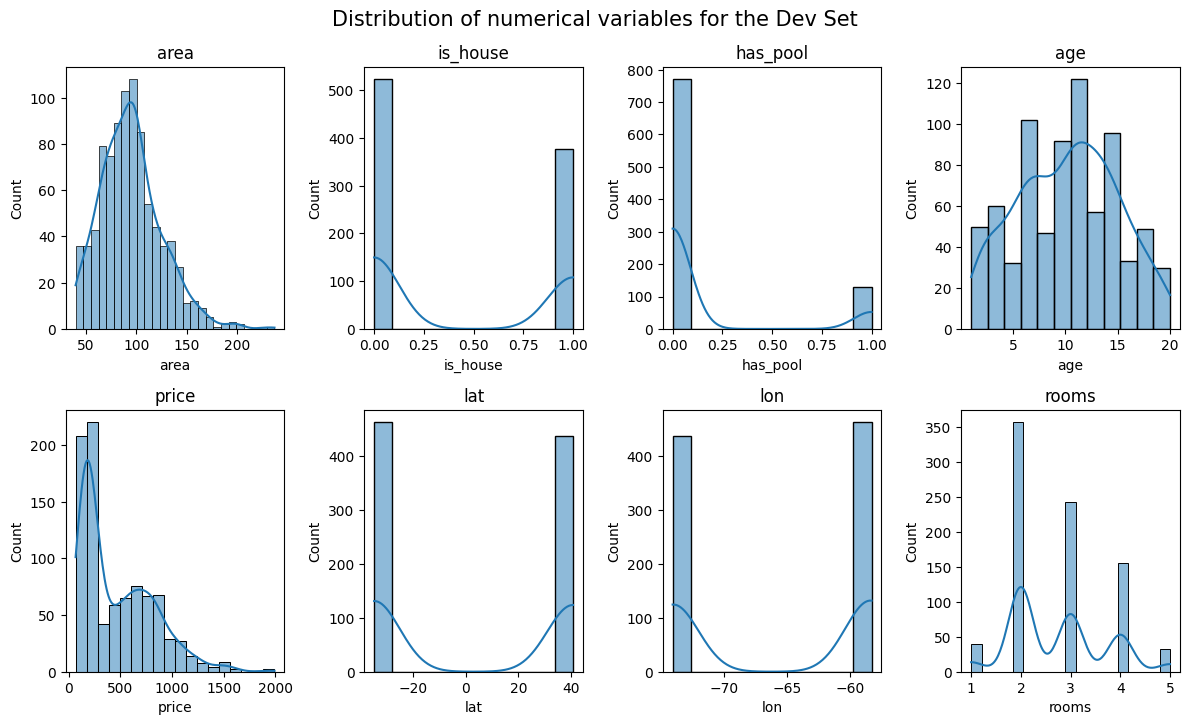

In [80]:
plot_distributions(units_converted_dev_df, "Dev")

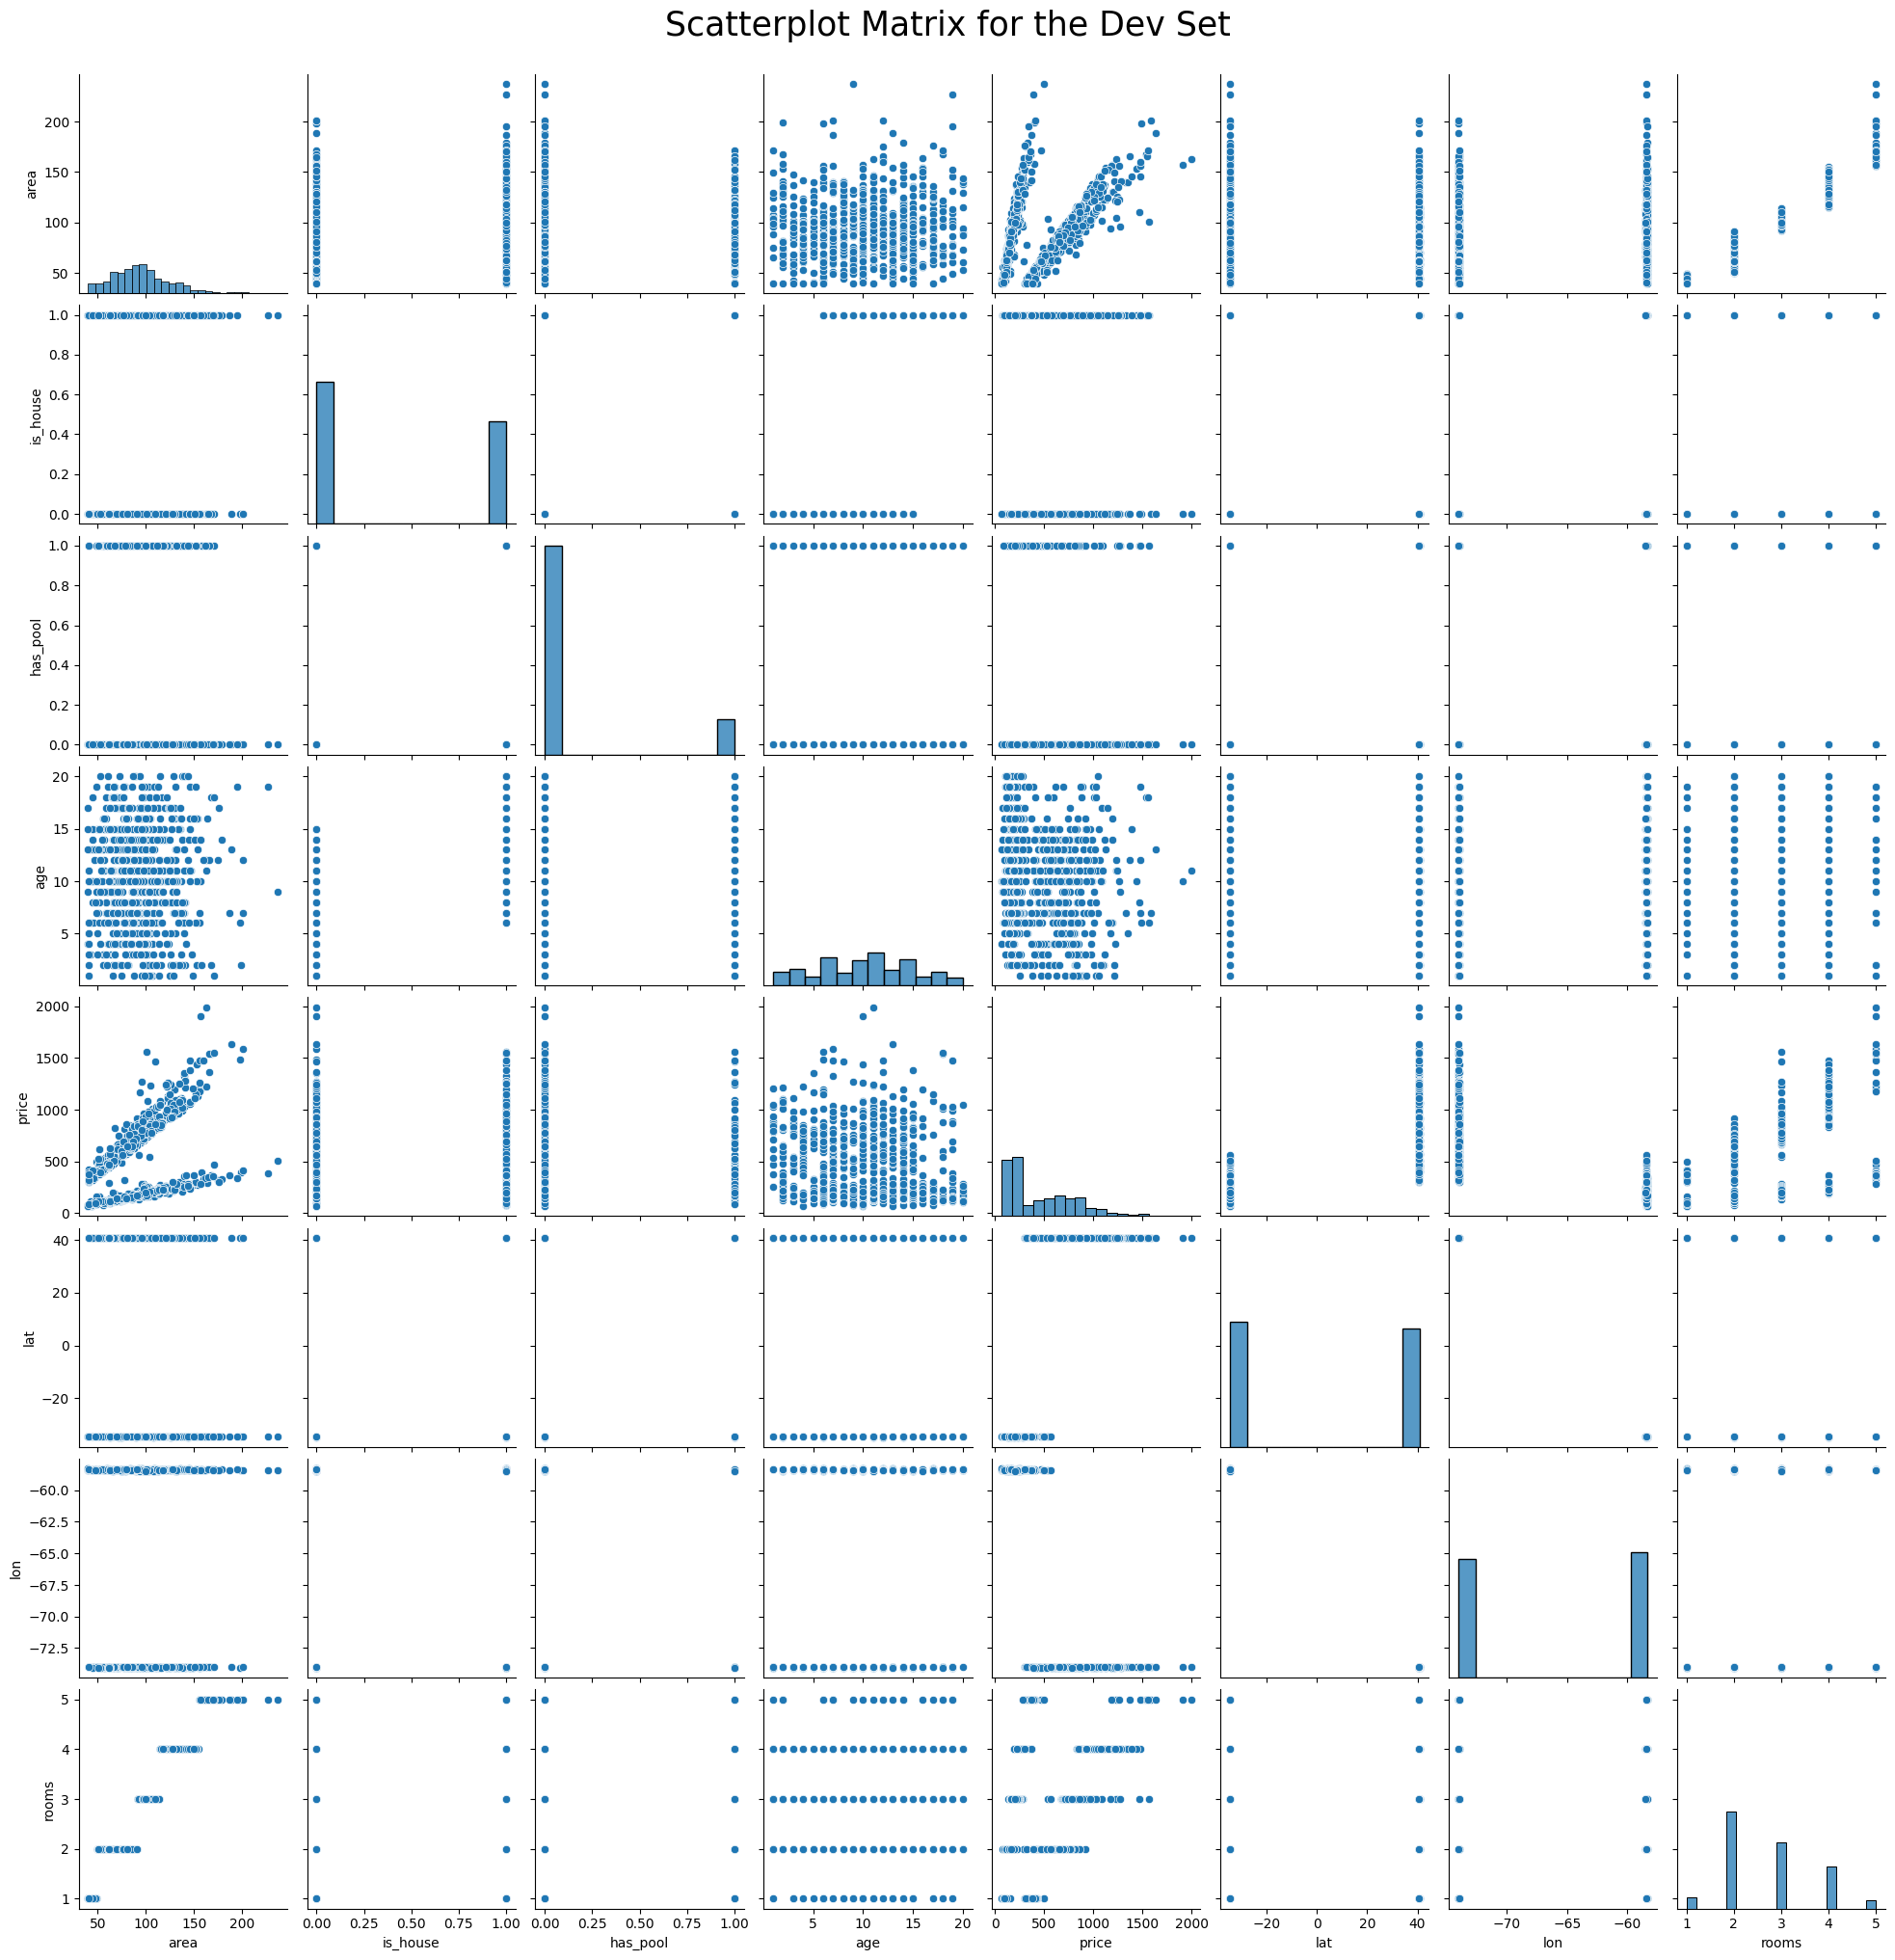

In [81]:
plot_scatter_matrix(units_converted_dev_df, "Dev")

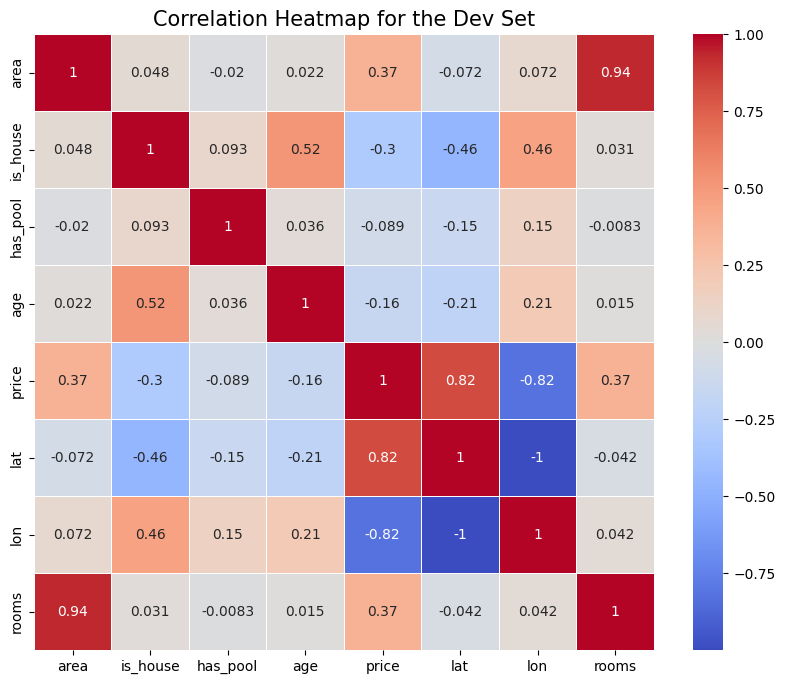

In [82]:
plot_correlation(units_converted_dev_df, "the Dev Set")

#### 1.3) Separación en Train y Validation

Para evitar leaking, separamos el dataset en train y validation antes de estandarizar/escalar los datos y acomodar los valores faltantes.

In [83]:
from src.data_splitting import split_and_save_train_val

In [84]:
train_df, val_df = split_and_save_train_val(units_converted_dev_df, "raw/casas_train.csv", "raw/casas_val.csv")

OSError: Cannot save file into a non-existent directory: 'data\processed\raw'

Ahora continuamos con la estandarización o escalamiento para poder estimar los datos faltantes en el set de train, y nos almacenamos los estadísticos para poder aplicar la misma transformación al set de validación.

#### estandarizamos o escalamos los datos según corresponde

hacemos estandarización (Z-score normalization) cuando asumimos que los datos provienenen de una distribución aproximadamente normal
$$x' = \frac{x - \mu}{\sigma}$$

Y hacemos reescalado cuando cuando los datos no son normales  
Una opción común es Min-Max Scaling:
$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

A partir de la observación de la distribución de las variables decido hacer lo siguiente:  

Estandarizo:  
age (aproximadamente normal), rooms (discreta pero la estandarización ayuda)  
todavía no resolví los nulls así que aún no estandarizo.

Reescalo:   
area y price están sesgadas a la derecha (colas largas)  
la función log anda bien cuando los datos tienen una cola larga hacia la derecha $\rightarrow$ Comprime los valores altos y expande los valores bajos.  
price = log(price + 1) (y hago un ajuste inverso después de la predicción)  
area = log(area + 1) y después estandarizar  
El log hace que los valores grandes no dominen el modelo y mejora la linealidad

No hago nada con las binarias: has_pool, is_house  
lat y lon las analizaremos más adelante con feature engenieering

In [ ]:
from src.preprocessing import compute_statistics, scale_df

In [ ]:
train_stats = compute_statistics(train_df)

casas_train_transformed = scale_df(train_df, train_stats)
casas_val_transformed = scale_df(val_df, train_stats)
casas_test_transformed = scale_df(units_converted_test_df, train_stats)

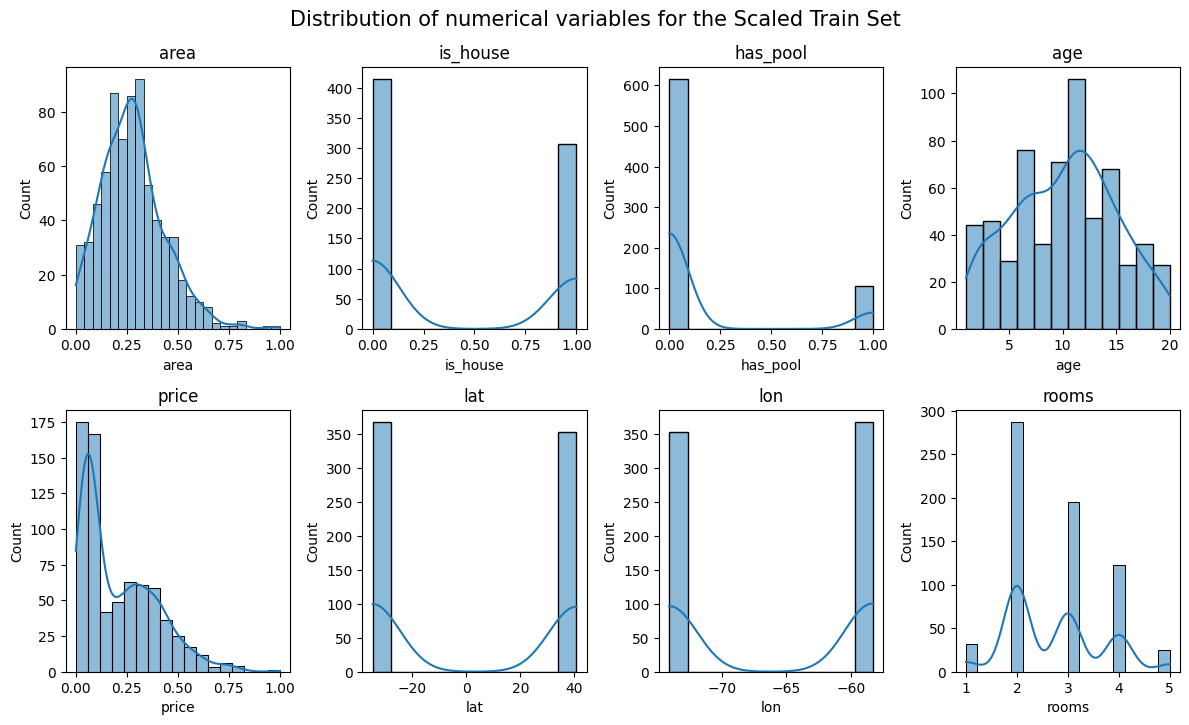

In [ ]:
plot_distributions(casas_train_transformed, "Scaled Train")

área y price entre 0 y 1

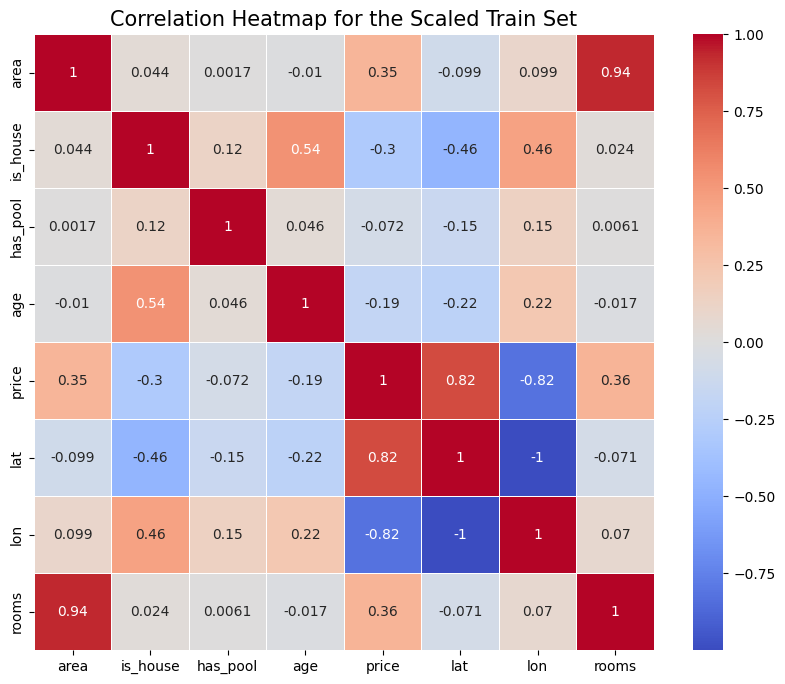

In [ ]:
plot_correlation(casas_train_transformed, "the Scaled Train Set")

#### Solucionamos ahora los problemas de nulls

##### Rooms

estimo la cantidad de rooms en base al área

visualizo la relación para ver qué regresión usar

In [ ]:
from src.plotting import plot_rooms_vs_area

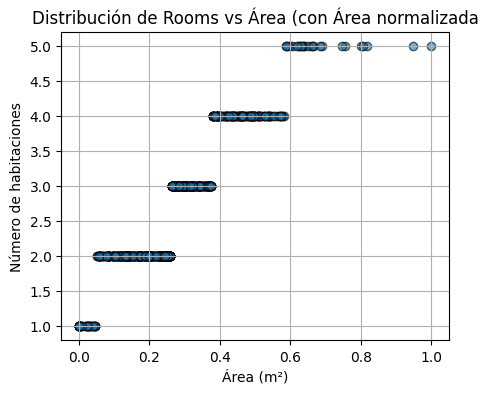

In [ ]:
plot_rooms_vs_area(casas_train_transformed, '(con Área normalizada')

In [ ]:
from src.models import predict_rooms_train_test, predict_rooms_no_split, complete_missing_rooms_values

In [ ]:
# Entrenar en train
print("divididendo el dataset para tener una métrica de precisión (haciendo split de testeo dentro del dataset de train_df)")
predict_rooms_train_test(casas_train_transformed)
print("\nEntrenando con todo el dataset de train_df")
W_d, b_d, mean_d, std_d = predict_rooms_no_split(casas_train_transformed)

# Uso los mismos pesos
print("\nCompletando valores faltantes en todos los datasets con las métricas calculadas a partir de train_df")
casas_train_rooms_complete = complete_missing_rooms_values(casas_train_transformed, W_d, b_d, mean_d, std_d)
casas_val_rooms_complete = complete_missing_rooms_values(casas_val_transformed, W_d, b_d, mean_d, std_d)
casas_test_rooms_complete = complete_missing_rooms_values(casas_test_transformed, W_d, b_d, mean_d, std_d)


divididendo el dataset para tener una métrica de precisión (haciendo split de testeo dentro del dataset de train_df)
Época 0, Pérdida Train: 0.3214, Pérdida Val: 0.3211
Época 5000, Pérdida Train: 0.0578, Pérdida Val: 0.0564
Época 10000, Pérdida Train: 0.0446, Pérdida Val: 0.0428
Época 15000, Pérdida Train: 0.0385, Pérdida Val: 0.0363
Época 20000, Pérdida Train: 0.0348, Pérdida Val: 0.0322
Época 25000, Pérdida Train: 0.0322, Pérdida Val: 0.0294
Precisión en el conjunto de prueba de train_df: 0.9774

Entrenando con todo el dataset de train_df
Época 0, Pérdida Train: 0.3228, Pérdida Val: 0.3228
Época 5000, Pérdida Train: 0.0572, Pérdida Val: 0.0555
Época 10000, Pérdida Train: 0.0442, Pérdida Val: 0.0432
Época 15000, Pérdida Train: 0.0381, Pérdida Val: 0.0376
Época 20000, Pérdida Train: 0.0344, Pérdida Val: 0.0343
Época 25000, Pérdida Train: 0.0318, Pérdida Val: 0.0320

Completando valores faltantes en todos los datasets con las métricas calculadas a partir de train_df
58 valores faltantes

##### Age

estimo las ages que faltan, con aprendizaje supervisado utilizando las features que más correlacion en módulo tienen con age $\rightarrow$ is_house, price, pca_latlon_1

In [ ]:
from src.plotting import plot_age_vs

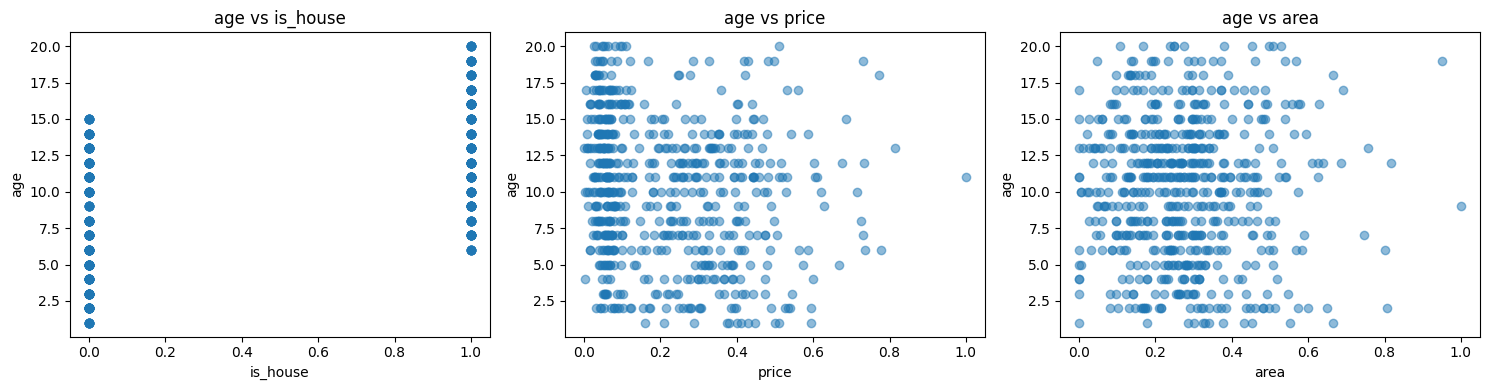

In [ ]:
plot_age_vs(casas_train_rooms_complete, features=["is_house", "price", "area"])

In [ ]:
from src.models import evaluate_complete_model_age, train_regression_for_age, complete_missing_age_values


In [ ]:
features_seleccionadas = ['is_house', 'price', 'area']

# Entrenar evaluando el modelo
theta, mean_train, std_train = evaluate_complete_model_age(casas_train_rooms_complete, features_seleccionadas, grado=1)

# Entrenar con todo el dataset
theta_final, mean_final, std_final = train_regression_for_age(casas_train_rooms_complete, features_seleccionadas, grado=1)

casas_train_complete = complete_missing_age_values(casas_train_rooms_complete, theta_final, mean_final, std_final, features_seleccionadas, grado=1)
casas_val_complete = complete_missing_age_values(casas_val_rooms_complete, theta_final, mean_final, std_final, features_seleccionadas, grado=1)
casas_test_complete = complete_missing_age_values(casas_test_rooms_complete, theta_final, mean_final, std_final, features_seleccionadas, grado=1)


Train RMSE: 4.0405
Validation RMSE: 3.7051
Test RMSE: 4.2650
107 valores faltantes en 'age' completados.
23 valores faltantes en 'age' completados.
16 valores faltantes en 'age' completados.


In [ ]:
complete_train_stats = compute_statistics(casas_train_complete)

casas_train_complete= scale_df(casas_train_complete, complete_train_stats, missing_values=True)
casas_val_complete = scale_df(casas_val_complete, complete_train_stats, missing_values=True)
casas_test_complete = scale_df(casas_test_complete, complete_train_stats, missing_values=True)

In [ ]:
from src.utils import save_csv

save_csv(casas_train_complete, "data/processed/casas_train_corregido.csv")
save_csv(casas_val_complete, "data/processed/casas_val_corregido.csv")
save_csv(casas_test_complete, "data/processed/casas_test_corregido.csv")


Dataset guardado como 'casas_train_corregido.csv'.
Dataset guardado como 'casas_val_corregido.csv'.
Dataset guardado como 'casas_test_corregido.csv'.


### 2)

implementación de la clase Linear Regression en src.models

In [ ]:
vivienda_Amanda_df = pd.read_csv("vivienda_Amanda.csv")
units_vivienda_Amanda_df = area_units_conversion(vivienda_Amanda_df)
vivienda_Amanda_scaled = scale_df(units_vivienda_Amanda_df)
# vivienda_Amanda_transformed = pca_latlon(vivienda_Amanda_scaled)
vivienda_Amanda_scaled.head(1)
# vivienda_Amanda_scaled = scale_df(units_vivienda_Amanda_df, missing_values=True)



# guardar_csv(vivienda_Amanda_transformed, "vivienda_Amanda_corregido.csv")

TypeError: scale_df() missing 1 required positional argument: 'stats'